# Глава 6. Дискретное косинусное преобразование: упражнения 6.1–6.3


In [1]:
import os
import time
import warnings
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

try:
    from scipy.fft import dct, idct, rfft, irfft
except ImportError:  # для старых версий SciPy
    from scipy.fftpack import dct, idct
    from numpy.fft import rfft, irfft

from scipy.io import wavfile
from IPython.display import Audio, display

try:
    import pandas as pd
except Exception:
    pd = None

PI2 = 2 * np.pi
rng = np.random.default_rng(17)

plt.rcParams['figure.figsize'] = (9, 5)

In [2]:
def synthesize2(amps, fs, ts):
    """Синтез суммы косинусов через матрицу.

    amps: массив амплитуд
    fs: массив частот
    ts: массив моментов времени
    """
    args = np.outer(ts, fs)
    M = np.cos(PI2 * args)
    ys = np.dot(M, amps)
    return ys


def analyze1(ys, fs, ts):
    """Анализ общего случая: решаем M a = y.

    Это концептуально простой, но дорогой вариант.
    """
    args = np.outer(ts, fs)
    M = np.cos(PI2 * args)
    amps = np.linalg.solve(M, ys)
    return amps


def analyze2(ys, fs, ts):
    """Анализ ортогонального случая: умножаем на M^T с масштабированием.

    Корректен при специальном выборе ts и fs, как в ДКП-IV.
    """
    args = np.outer(ts, fs)
    M = np.cos(PI2 * args)
    amps = np.dot(M, ys) / 2
    return amps


def dct_iv_matrix(ys):
    """Матричная реализация ДКП-IV из главы.
    """
    N = len(ys)
    ts = (0.5 + np.arange(N)) / N
    fs = (0.5 + np.arange(N)) / 2
    args = np.outer(ts, fs)
    M = np.cos(PI2 * args)
    amps = np.dot(M, ys) / 2
    return amps


def scipy_dct_fast(ys, fs=None, ts=None):
    """Быстрая библиотечная ДКП для сравнения времени работы.

    Здесь важна скорость, а не точное совпадение нормировки с dct_iv_matrix.
    """
    return dct(ys, type=2, norm='ortho')

In [3]:
# Быстрая проверка, что синтез и анализ согласованы для ДКП-IV.
amps = np.array([0.6, 0.25, 0.1, 0.05])
N = len(amps)
ts = (0.5 + np.arange(N)) / N
fs = (0.5 + np.arange(N)) / 2
ys = synthesize2(amps, fs, ts)
amps2 = analyze2(ys, fs, ts)

print('исходные амплитуды:     ', amps)
print('восстановленные амплитуды:', np.round(amps2, 12))
print('максимальная ошибка:     ', np.max(np.abs(amps - amps2)))

исходные амплитуды:      [0.6  0.25 0.1  0.05]
восстановленные амплитуды: [0.6  0.25 0.1  0.05]
максимальная ошибка:      5.551115123125783e-17


## Упражнение 6.1. Проверка времени работы

Задание: убедиться экспериментально, что `analyze1` растёт существенно быстрее, чем `analyze2`, а библиотечная ДКП из SciPy быстрее обеих матричных реализаций.

In [4]:
def make_test_data(N, seed=17):
    """Данные с тем же выбором ts и fs, который используется в ДКП-IV."""
    local_rng = np.random.default_rng(seed)
    ys = local_rng.normal(size=N)
    ts = (0.5 + np.arange(N)) / N
    fs = (0.5 + np.arange(N)) / 2
    return ys, fs, ts


def best_runtime(func, ys, fs, ts, target_seconds=0.04, repeat=3, max_loops=4096):
    """Оценивает лучшее время одного вызова функции.

    Для очень быстрых функций автоматически увеличивает число повторов,
    чтобы измерение было менее шумным.
    """
    loops = 1
    while True:
        start = time.perf_counter()
        for _ in range(loops):
            func(ys, fs, ts)
        elapsed = time.perf_counter() - start
        if elapsed >= target_seconds or loops >= max_loops:
            break
        loops *= 2

    best = float('inf')
    for _ in range(repeat):
        start = time.perf_counter()
        for _ in range(loops):
            func(ys, fs, ts)
        elapsed = time.perf_counter() - start
        best = min(best, elapsed / loops)

    return best


def run_speed_test(ns, func, label):
    rows = []
    for N in ns:
        print(f'{label}: N={N}')
        ys, fs, ts = make_test_data(int(N))
        seconds = best_runtime(func, ys, fs, ts)
        rows.append({'method': label, 'N': int(N), 'seconds': seconds})
    return rows


def estimate_slope(ns, seconds):
    """Наклон прямой на log-log графике."""
    ns = np.asarray(ns, dtype=float)
    seconds = np.asarray(seconds, dtype=float)
    return np.polyfit(np.log(ns), np.log(seconds), 1)[0]

In [5]:
# Диапазон для analyze1 ограничен: решение системы быстро становится дорогим.
ns_slow = 2 ** np.arange(5, 11)      # 32 ... 1024
ns_medium = 2 ** np.arange(5, 12)    # 32 ... 2048
ns_fast = 2 ** np.arange(5, 16)      # 32 ... 32768

rows = []
rows += run_speed_test(ns_slow, analyze1, 'analyze1: solve')
rows += run_speed_test(ns_medium, analyze2, 'analyze2: matrix dot')
rows += run_speed_test(ns_medium, lambda ys, fs, ts: dct_iv_matrix(ys), 'dct_iv: matrix')
rows += run_speed_test(ns_fast, scipy_dct_fast, 'scipy dct: fast')

timing = pd.DataFrame(rows) if pd is not None else rows
if pd is not None:
    display(timing)
else:
    timing

analyze1: solve: N=32
analyze1: solve: N=64
analyze1: solve: N=128
analyze1: solve: N=256
analyze1: solve: N=512
analyze1: solve: N=1024
analyze2: matrix dot: N=32
analyze2: matrix dot: N=64
analyze2: matrix dot: N=128
analyze2: matrix dot: N=256
analyze2: matrix dot: N=512
analyze2: matrix dot: N=1024
analyze2: matrix dot: N=2048
dct_iv: matrix: N=32
dct_iv: matrix: N=64
dct_iv: matrix: N=128
dct_iv: matrix: N=256
dct_iv: matrix: N=512
dct_iv: matrix: N=1024
dct_iv: matrix: N=2048
scipy dct: fast: N=32
scipy dct: fast: N=64
scipy dct: fast: N=128
scipy dct: fast: N=256
scipy dct: fast: N=512
scipy dct: fast: N=1024
scipy dct: fast: N=2048
scipy dct: fast: N=4096
scipy dct: fast: N=8192
scipy dct: fast: N=16384
scipy dct: fast: N=32768


,method,N,seconds
0,analyze1: solve,32,0.000051
1,analyze1: solve,64,0.000174
2,analyze1: solve,128,0.000631
3,analyze1: solve,256,0.006289
4,analyze1: solve,512,0.046326
5,analyze1: solve,1024,0.097332
6,analyze2: matrix dot,32,0.000031
7,analyze2: matrix dot,64,0.000106
8,analyze2: matrix dot,128,0.000391
9,analyze2: matrix dot,256,0.001434


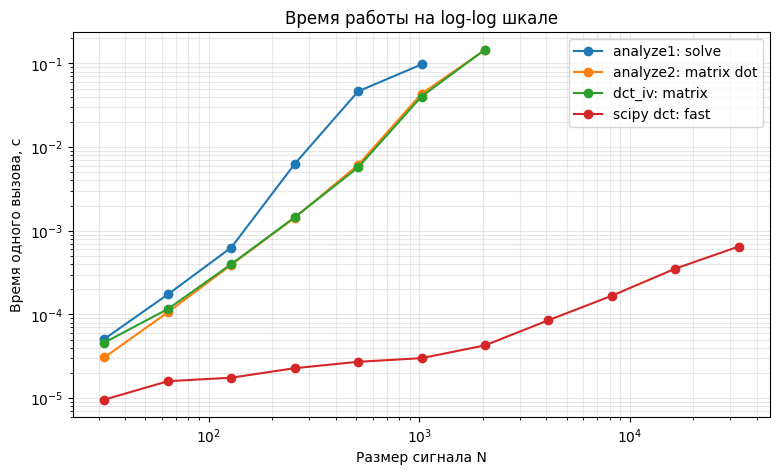

Оценки наклона на log-log графике:
analyze1: solve       : 2.34
analyze2: matrix dot  : 2.07
dct_iv: matrix        : 1.99
scipy dct: fast       : 0.57


In [6]:
# График и оценки наклонов.
plt.figure()
slopes = {}

if pd is not None:
    grouped = timing.groupby('method')
    for method, group in grouped:
        group = group.sort_values('N')
        plt.loglog(group['N'], group['seconds'], marker='o', label=method)
        slopes[method] = estimate_slope(group['N'], group['seconds'])
else:
    # запасной вариант без pandas
    methods = sorted(set(row['method'] for row in timing))
    for method in methods:
        group = [row for row in timing if row['method'] == method]
        xs = [row['N'] for row in group]
        ys_time = [row['seconds'] for row in group]
        plt.loglog(xs, ys_time, marker='o', label=method)
        slopes[method] = estimate_slope(xs, ys_time)

plt.xlabel('Размер сигнала N')
plt.ylabel('Время одного вызова, с')
plt.title('Время работы на log-log шкале')
plt.grid(True, which='both', alpha=0.3)
plt.legend()
plt.show()

print('Оценки наклона на log-log графике:')
for method, slope in slopes.items():
    print(f'{method:22s}: {slope:.2f}')

### Вывод по упражнению 6.1

- `analyze1` — самый медленный метод. Теоретически он должен вести себя как $n^3$, потому что решает систему линейных уравнений. На небольших `N` оценка наклона может быть ближе к 2: это нормально и совпадает с авторским наблюдением, потому что на малых размерах сильны накладные расходы и особенности реализации `np.linalg.solve`.
- `analyze2` и матричный `dct_iv` должны давать наклон около 2, так как строят матрицу размера `N × N` и умножают её на вектор.
- `scipy dct` должен быть значительно быстрее; его кривая часто не похожа на прямую с целым наклоном, потому что быстрая ДКП имеет порядок примерно $n\log n$.

## Упражнение 6.2. Сжатие звука с помощью ДКП



In [7]:
def to_float_mono(data):
    """Преобразует WAV-данные к mono float64 в диапазоне примерно [-1, 1]."""
    data = np.asarray(data)

    if data.ndim == 2:
        data = data.mean(axis=1)

    if np.issubdtype(data.dtype, np.integer):
        max_value = np.iinfo(data.dtype).max
        data = data.astype(np.float64) / max_value
    else:
        data = data.astype(np.float64)

    return data


def normalize_audio(ys, peak=0.95):
    ys = np.asarray(ys, dtype=np.float64)
    max_abs = np.max(np.abs(ys)) if len(ys) else 0
    if max_abs > 0:
        ys = ys / max_abs * peak
    return ys


def synthesize_demo_audio(framerate=11025, duration=3.0):
    """Запасной аудиопример, если WAV-файл не найден.

    Это не настоящая музыка, но сигнал содержит несколько гармоник,
    шум и огибающую, поэтому подходит для отладки алгоритма.
    """
    t = np.arange(int(framerate * duration)) / framerate
    env = np.minimum(1, t / 0.08) * np.exp(-0.15 * t)
    ys = (
        0.55 * np.sin(2 * np.pi * 220 * t)
        + 0.28 * np.sin(2 * np.pi * 440 * t + 0.3)
        + 0.15 * np.sin(2 * np.pi * 660 * t + 1.1)
        + 0.08 * np.sin(2 * np.pi * 880 * t + 2.0)
    )
    ys = ys * env + 0.015 * rng.normal(size=len(t))
    return framerate, normalize_audio(ys)


def load_audio(path=None):
    """Загружает WAV или создаёт запасной сигнал.

    Чтобы использовать свою запись речи/музыки, положите WAV рядом с блокнотом
    и укажите путь в переменной audio_path ниже.
    """
    candidates = []
    if path:
        candidates.append(Path(path))

    # Файл из авторского решения, если он уже лежит рядом с блокнотом.
    candidates.append(Path('100475__iluppai__saxophone-weep.wav'))

    for candidate in candidates:
        if candidate.exists():
            framerate, data = wavfile.read(candidate)
            ys = normalize_audio(to_float_mono(data))
            print(f'Загружен файл: {candidate}, framerate={framerate}, samples={len(ys)}')
            return framerate, ys

    print('WAV-файл не найден; используется синтетический демонстрационный сигнал.')
    return synthesize_demo_audio()


def snr_db(original, processed):
    """Signal-to-noise ratio в децибелах."""
    n = min(len(original), len(processed))
    original = original[:n]
    processed = processed[:n]
    noise = original - processed
    signal_power = np.mean(original ** 2)
    noise_power = np.mean(noise ** 2)
    if noise_power == 0:
        return np.inf
    return 10 * np.log10(signal_power / noise_power)


def float_to_int16(ys):
    ys = normalize_audio(ys, peak=0.98)
    return np.int16(np.clip(ys, -1, 1) * 32767)

In [8]:
# Укажите путь к своему WAV-файлу или оставьте None.
audio_path = None

framerate, ys = load_audio(audio_path)
print(f'Длительность: {len(ys) / framerate:.2f} с')

Audio(ys, rate=framerate)

WAV-файл не найден; используется синтетический демонстрационный сигнал.
Длительность: 3.00 с


In [9]:
def dct_compress_wave(ys, seg_length=1024, keep_fraction=0.10, hop_length=None):
    """Сжимает сигнал: оставляет keep_fraction самых больших DCT-коэффициентов в каждом сегменте.

    ys: одномерный аудиосигнал
    seg_length: длина сегмента в отсчётах
    keep_fraction: доля коэффициентов, которые сохраняются в каждом сегменте
    hop_length: шаг между сегментами; по умолчанию 50% перекрытие

    returns: восстановленный сигнал, статистика
    """
    ys = np.asarray(ys, dtype=np.float64)
    if hop_length is None:
        hop_length = seg_length // 2

    keep_fraction = float(keep_fraction)
    if not (0 < keep_fraction <= 1):
        raise ValueError('keep_fraction должен быть в диапазоне (0, 1].')

    window = np.hanning(seg_length)
    pad = seg_length
    padded = np.pad(ys, (pad, pad), mode='constant')

    out = np.zeros_like(padded)
    weight = np.zeros_like(padded)

    total_coeffs = 0
    kept_coeffs = 0
    frames = 0

    for start in range(0, len(padded) - seg_length + 1, hop_length):
        frame = padded[start:start + seg_length] * window
        coeffs = dct(frame, type=2, norm='ortho')

        k = max(1, int(np.ceil(keep_fraction * len(coeffs))))
        if k < len(coeffs):
            # Индексы k наибольших по модулю коэффициентов.
            keep_idx = np.argpartition(np.abs(coeffs), -k)[-k:]
            compressed_coeffs = np.zeros_like(coeffs)
            compressed_coeffs[keep_idx] = coeffs[keep_idx]
        else:
            compressed_coeffs = coeffs.copy()

        rec = idct(compressed_coeffs, type=2, norm='ortho')
        out[start:start + seg_length] += rec * window
        weight[start:start + seg_length] += window ** 2

        total_coeffs += len(coeffs)
        kept_coeffs += np.count_nonzero(compressed_coeffs)
        frames += 1

    valid = weight > 1e-12
    out[valid] /= weight[valid]
    out = out[pad:pad + len(ys)]
    out = normalize_audio(out)

    stats = {
        'frames': frames,
        'total_coeffs': total_coeffs,
        'kept_coeffs': kept_coeffs,
        'removed_coeffs': total_coeffs - kept_coeffs,
        'kept_percent': 100 * kept_coeffs / total_coeffs,
        'removed_percent': 100 * (total_coeffs - kept_coeffs) / total_coeffs,
    }
    return out, stats

In [10]:
# Проверим несколько степеней сжатия.
keep_values = [0.50, 0.25, 0.10, 0.05, 0.02]
compressed_versions = {}
summary_rows = []

for keep in keep_values:
    comp, stats = dct_compress_wave(ys, seg_length=1024, keep_fraction=keep)
    compressed_versions[keep] = comp
    summary_rows.append({
        'keep_fraction': keep,
        'kept_percent': stats['kept_percent'],
        'removed_percent': stats['removed_percent'],
        'SNR_dB': snr_db(ys, comp),
    })

summary = pd.DataFrame(summary_rows) if pd is not None else summary_rows
if pd is not None:
    display(summary)
else:
    summary

,keep_fraction,kept_percent,removed_percent,SNR_dB
0,0.50,49.253731,50.746269,40.899550
1,0.25,24.626866,75.373134,34.051175
2,0.10,9.908465,90.091535,29.819826
3,0.05,5.002332,94.997668,27.922885
4,0.02,2.020173,97.979827,23.922115


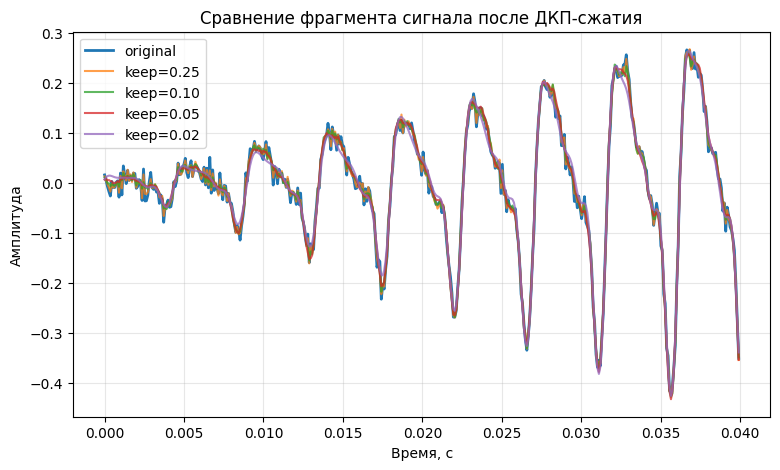

In [11]:
# График: исходный сигнал и несколько восстановленных вариантов на коротком фрагменте.
seconds_to_show = 0.04
n_show = int(seconds_to_show * framerate)
t = np.arange(n_show) / framerate

plt.figure()
plt.plot(t, ys[:n_show], label='original', linewidth=2)
for keep in [0.25, 0.10, 0.05, 0.02]:
    plt.plot(t, compressed_versions[keep][:n_show], alpha=0.75, label=f'keep={keep:.2f}')
plt.xlabel('Время, с')
plt.ylabel('Амплитуда')
plt.title('Сравнение фрагмента сигнала после ДКП-сжатия')
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

In [12]:
# Прослушивание: сначала оригинал, затем несколько вариантов.
print('Оригинал')
display(Audio(ys, rate=framerate))

for keep in [0.25, 0.10, 0.05, 0.02]:
    print(f'Сохраняем {100*keep:.0f}% коэффициентов, удаляем {100*(1-keep):.0f}%')
    display(Audio(compressed_versions[keep], rate=framerate))

Оригинал


Сохраняем 25% коэффициентов, удаляем 75%


Сохраняем 10% коэффициентов, удаляем 90%


Сохраняем 5% коэффициентов, удаляем 95%


Сохраняем 2% коэффициентов, удаляем 98%


In [ ]:
# По желанию сохраним один из вариантов в WAV.
keep_to_save = 0.10
out_path = f'dct_compressed_keep_{int(100 * keep_to_save):02d}.wav'
wavfile.write(out_path, framerate, float_to_int16(compressed_versions[keep_to_save]))
print(f'Сохранено: {out_path}')

## Упражнение 6.3. Фаза и восприятие звука


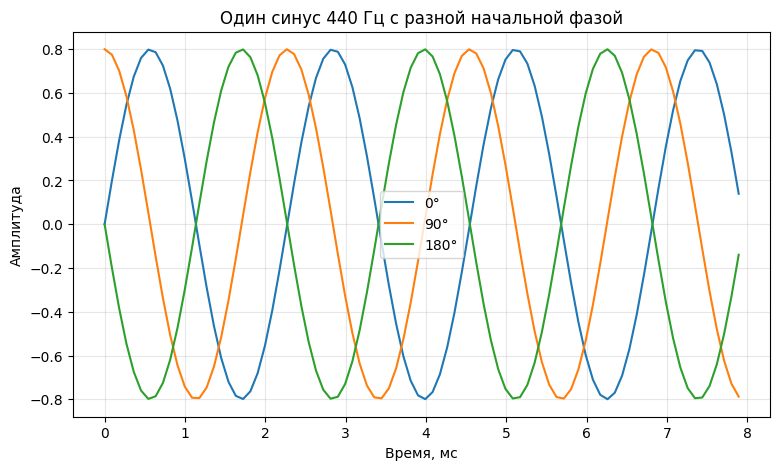

0°


90°


180°


In [13]:
def plot_first_ms(signals, labels, framerate, ms=20, title=''):
    n = int(framerate * ms / 1000)
    t = np.arange(n) / framerate * 1000
    plt.figure()
    for sig, label in zip(signals, labels):
        plt.plot(t, sig[:n], label=label)
    plt.xlabel('Время, мс')
    plt.ylabel('Амплитуда')
    plt.title(title)
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.show()


# 1) Один синус: фаза меняет положение волны во времени, но тон остается тем же.
t = np.arange(framerate) / framerate
sine_0 = 0.8 * np.sin(2 * np.pi * 440 * t)
sine_90 = 0.8 * np.sin(2 * np.pi * 440 * t + np.pi / 2)
sine_180 = 0.8 * np.sin(2 * np.pi * 440 * t + np.pi)

plot_first_ms([sine_0, sine_90, sine_180], ['0°', '90°', '180°'], framerate, ms=8,
              title='Один синус 440 Гц с разной начальной фазой')

print('0°')
display(Audio(sine_0, rate=framerate))
print('90°')
display(Audio(sine_90, rate=framerate))
print('180°')
display(Audio(sine_180, rate=framerate))

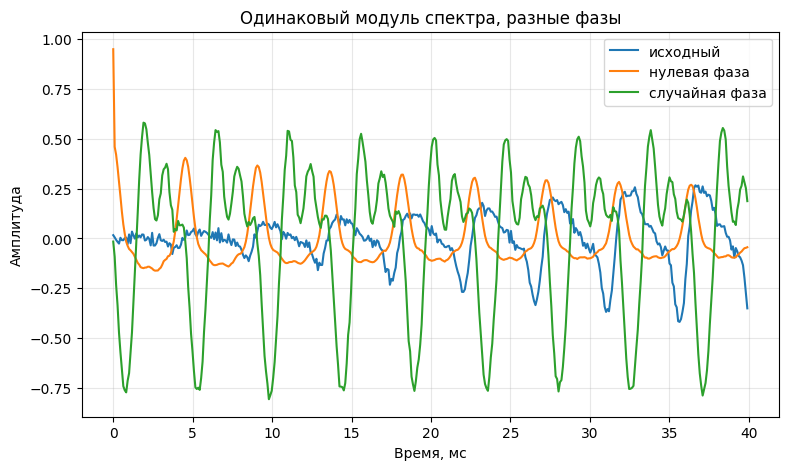

In [14]:
def zero_phase_signal(ys):
    """Сохраняет модуль спектра, но ставит фазы равными нулю."""
    spec = rfft(ys)
    mag = np.abs(spec)
    return normalize_audio(irfft(mag, n=len(ys)))


def random_phase_signal(ys, seed=17):
    """Сохраняет модуль спектра, но заменяет фазы случайными."""
    local_rng = np.random.default_rng(seed)
    spec = rfft(ys)
    mag = np.abs(spec)
    phases = local_rng.uniform(-np.pi, np.pi, len(spec))

    # DC-компонента и частота Найквиста должны оставаться вещественными.
    phases[0] = 0
    if len(ys) % 2 == 0:
        phases[-1] = 0

    new_spec = mag * np.exp(1j * phases)
    return normalize_audio(irfft(new_spec, n=len(ys)))


# Возьмем не слишком длинный фрагмент, чтобы эффект было удобно слушать.
duration = min(2.0, len(ys) / framerate)
n = int(duration * framerate)
fragment = normalize_audio(ys[:n])
fragment_zero_phase = zero_phase_signal(fragment)
fragment_random_phase = random_phase_signal(fragment)

plot_first_ms(
    [fragment, fragment_zero_phase, fragment_random_phase],
    ['исходный', 'нулевая фаза', 'случайная фаза'],
    framerate,
    ms=40,
    title='Одинаковый модуль спектра, разные фазы'
)

In [15]:
print('Исходный фрагмент')
display(Audio(fragment, rate=framerate))

print('Тот же модуль спектра, нулевые фазы')
display(Audio(fragment_zero_phase, rate=framerate))

print('Тот же модуль спектра, случайные фазы')
display(Audio(fragment_random_phase, rate=framerate))

Исходный фрагмент


Тот же модуль спектра, нулевые фазы


Тот же модуль спектра, случайные фазы


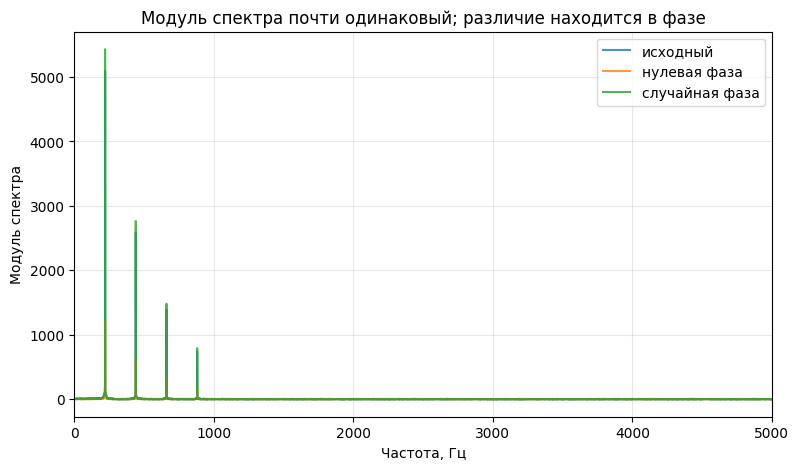

In [17]:
# Сравним спектральные амплитуды: они почти совпадают, хотя звук и форма волны меняются.
def magnitude_spectrum(ys, framerate):
    spec = rfft(ys)
    freqs = np.linspace(0, framerate / 2, len(spec))
    return freqs, np.abs(spec)

plt.figure()
for sig, label in [
    (fragment, 'исходный'),
    (fragment_zero_phase, 'нулевая фаза'),
    (fragment_random_phase, 'случайная фаза'),
]:
    freqs, mags = magnitude_spectrum(sig, framerate)
    plt.plot(freqs, mags, label=label, alpha=0.8)

plt.xlim(0, min(5000, framerate / 2))
plt.xlabel('Частота, Гц')
plt.ylabel('Модуль спектра')
plt.title('Модуль спектра почти одинаковый; различие находится в фазе')
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()